In [51]:
import pandas as pd
data= pd.read_csv("https://raw.githubusercontent.com/maimunarahma/ai-ml/main/Nural_network/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
import numpy as np
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[cols] = data[cols].replace(0, np.nan)


In [53]:
# Fill missing values with median
data.fillna(data.median(), inplace=True)

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [54]:
# Split features and target
X = data.drop("Outcome", axis=1).values
y = data["Outcome"].values


In [55]:
# encoding
data["AgeGroup"] = pd.cut(data["Age"], bins=[20,30,40,50,60,80], labels=["A","B","C","D","E"])
data = pd.get_dummies(data, columns=["AgeGroup"])

In [56]:
# Train-test split (stratified)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [57]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
# converting to pytporch tensor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [59]:
# dividind into batch size using dataloader + shuffling

def get_loader(X, y, batch_size=32):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [60]:
# shallow NN
class ShallowNN(nn.Module):
    def __init__(self, input_size, hidden_size, activation="relu"):
        super().__init__()

        act = nn.ReLU() if activation == "relu" else nn.Sigmoid()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            act,
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [61]:
# deep NN
class DeepNN(nn.Module):
    def __init__(self, input_size, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [62]:

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))

    return history

In [63]:
train_loader = get_loader(X_train, y_train, batch_size=32)
val_loader = get_loader(X_test, y_test, batch_size=32)

In [64]:
# train shallow model
shallow_model = ShallowNN(input_size=X.shape[1], hidden_size=16, activation="relu")
shallow_history = train_model(shallow_model, train_loader, val_loader, epochs=50, lr=0.001)

In [65]:
# train deep model
deep_model = DeepNN(input_size=X.shape[1] ,dropout=0.3)
deep_history = train_model(deep_model, train_loader, val_loader, epochs=100, lr=0.0005)

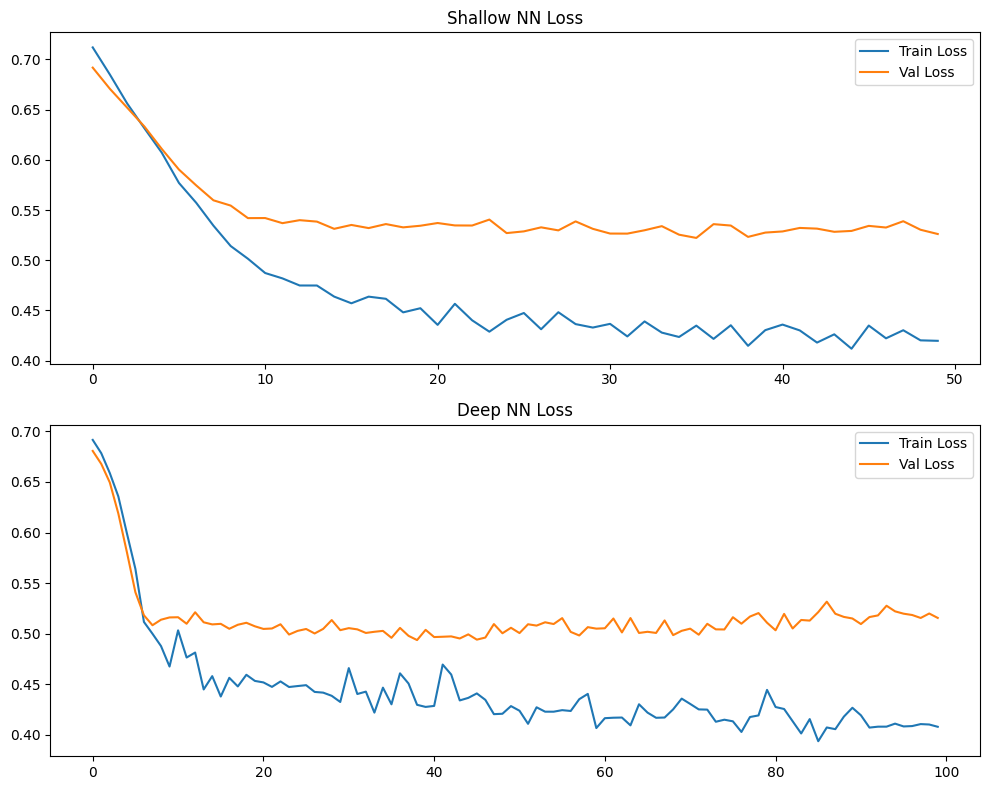

In [66]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(shallow_history["train_loss"], label="Train Loss")
ax[0].plot(shallow_history["val_loss"], label="Val Loss")
ax[0].set_title("Shallow NN Loss")
ax[0].legend()

ax[1].plot(deep_history["train_loss"], label="Train Loss")
ax[1].plot(deep_history["val_loss"], label="Val Loss")
ax[1].set_title("Deep NN Loss")
ax[1].legend()

plt.tight_layout()
plt.show()

In [67]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import seaborn as sns

In [68]:
def get_predictions(model, X):
    model.eval()
    with torch.no_grad():
        preds = model(X)
    return preds.numpy()

shallow_preds = get_predictions(shallow_model, X_test)
deep_preds = get_predictions(deep_model, X_test)

In [69]:
def evaluate(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob)
    }

shallow_metrics = evaluate(y_test, shallow_preds)
deep_metrics = evaluate(y_test, deep_preds)

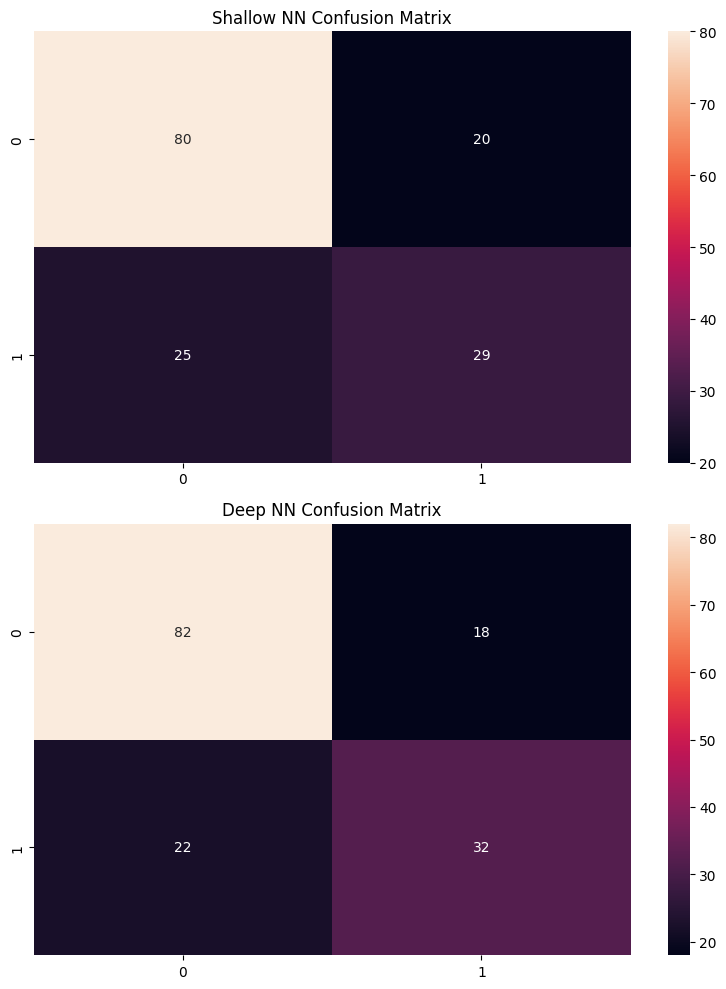

In [70]:
# confusion matrics
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

sns.heatmap(confusion_matrix(y_test, shallow_preds > 0.5),
            annot=True, fmt="d", ax=ax[0])
ax[0].set_title("Shallow NN Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, deep_preds > 0.5),
            annot=True, fmt="d", ax=ax[1])
ax[1].set_title("Deep NN Confusion Matrix")

plt.tight_layout()
plt.show()

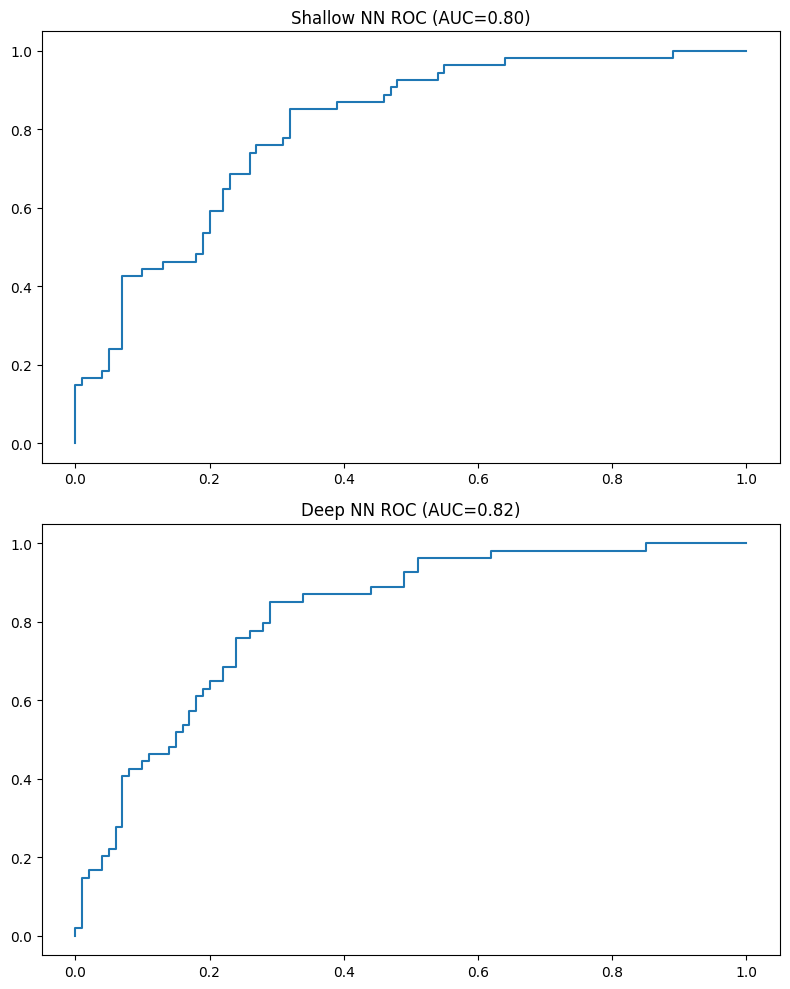

In [71]:
# ROC curve
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

fpr, tpr, _ = roc_curve(y_test, shallow_preds)
ax[0].plot(fpr, tpr)
ax[0].set_title(f"Shallow NN ROC (AUC={shallow_metrics['auc']:.2f})")

fpr, tpr, _ = roc_curve(y_test, deep_preds)
ax[1].plot(fpr, tpr)
ax[1].set_title(f"Deep NN ROC (AUC={deep_metrics['auc']:.2f})")

plt.tight_layout()
plt.show()

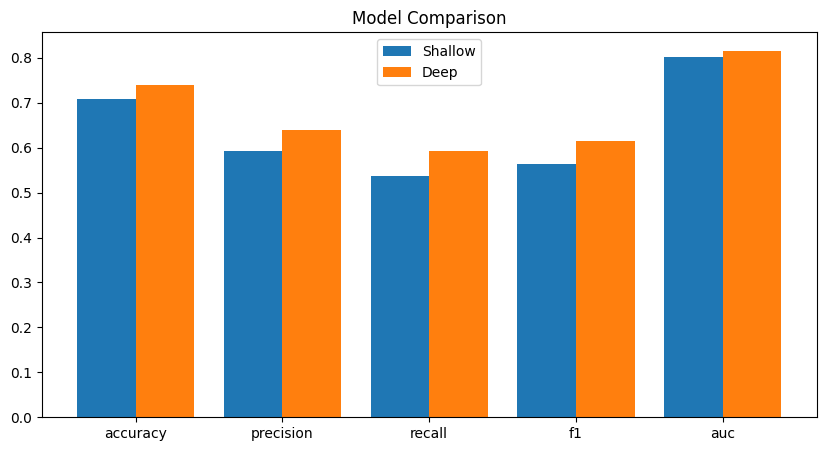

In [72]:
metrics = ["accuracy", "precision", "recall", "f1", "auc"]

shallow_vals = [shallow_metrics[m] for m in metrics]
deep_vals = [deep_metrics[m] for m in metrics]

x = np.arange(len(metrics))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, shallow_vals, 0.4, label="Shallow")
plt.bar(x + 0.2, deep_vals, 0.4, label="Deep")

plt.xticks(x, metrics)
plt.legend()
plt.title("Model Comparison")
plt.show()

In [73]:
print("SHALLOW NN")
print(shallow_model)

print("\nDEEP NN")
print(deep_model)

SHALLOW NN
ShallowNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

DEEP NN
DeepNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
